In [1]:
#Our task is to develop a “good-performing” decision support system that classifies text.
#our data set is sentiment analysis over tweets gathered during the stock market crash in 2022

In [1]:
#The sentiment of the tweets column consists of three categories: Positive, Neutral, Negative
# Data fields
# text: tweet
# text_sentiment: Positive, Neutral, Negative:
#     Positive->1, Neutral->0, Negative->2

In [2]:
# Install Spark NLP and PySpark and wordcloud and nltk
!pip install pyspark spark-nlp wordcloud nltk

# Start Spark NLP session
import sparknlp
spark = sparknlp.start()

In [3]:
from pyspark.sql.functions import col, when, regexp_replace, length, udf
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [4]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("nltk_pos_tagging")  
    .getOrCreate()
)

In [5]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
# read .csv file
custom_schema = StructType([
StructField('text', StringType(), True),
StructField('text_sentiment', IntegerType(), True)
])
df = spark.read.csv( 'stock_market_crash_2022.csv', header=True, schema=custom_schema, multiLine=True)
df.show()
df.printSchema()

+--------------------+--------------+
|                text|text_sentiment|
+--------------------+--------------+
|#bearmarket i exp...|             0|
|Mientras estÃ©s v...|             0|
|#ETH is gone_¦ð_#...|             0|
|It__ finally here...|             0|
|I don__ see it. #...|             0|
|$TSLA is cheap! J...|             0|
|I am a trader, wh...|             0|
|OpenSea removed t...|             0|
|Bhai sare Fintwit...|             0|
|   #stockmarketcrash|             0|
|R.I.P El Salvador...|             0|
|à¤¹à¤®à¥_ à¤¤à à¤...|             0|
|2021-\nDad - wher...|             0|
|#bearmarket  too ...|             0|
|Pura market down....|             0|
|@devchart 20k$ in...|             0|
|@CoinFlashx #Just...|             0|
|Even Stock market...|             0|
|#stockmarketcrash...|             0|
|Millionaires are ...|             0|
+--------------------+--------------+
only showing top 20 rows

root
 |-- text: string (nullable = true)
 |-- text_sentiment: 

In [6]:
df = df.na.drop()
df.groupBy("text_sentiment").count().show()

+--------------+-----+
|text_sentiment|count|
+--------------+-----+
|             1|  624|
|             2|  493|
|             0|  575|
+--------------+-----+



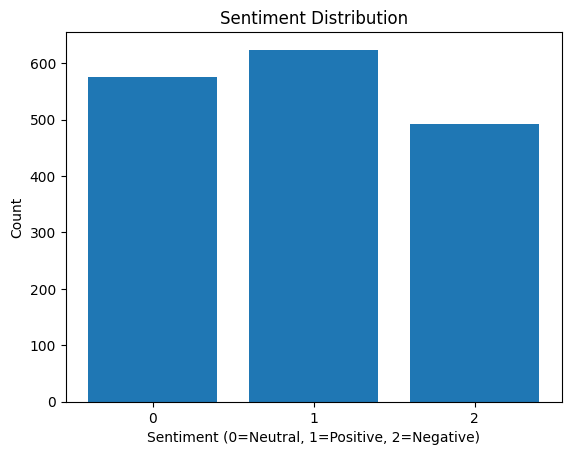

In [7]:
sentiment_counts = df.groupBy("text_sentiment").count().toPandas()
x = [0, 1, 2]
plt.bar(sentiment_counts["text_sentiment"], sentiment_counts["count"])
plt.xticks(x)
plt.xlabel("Sentiment (0=Neutral, 1=Positive, 2=Negative)")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.show()

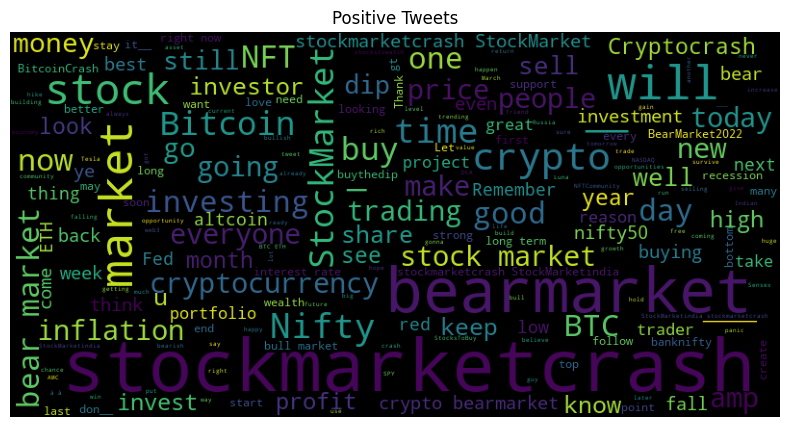

In [8]:
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400).generate(" ".join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    plt.title(title)
    plt.axis("off")
    plt.show()

positive_tweets = df.filter(col("text_sentiment") == 1).select("text").toPandas()["text"]
generate_wordcloud(positive_tweets, "Positive Tweets")

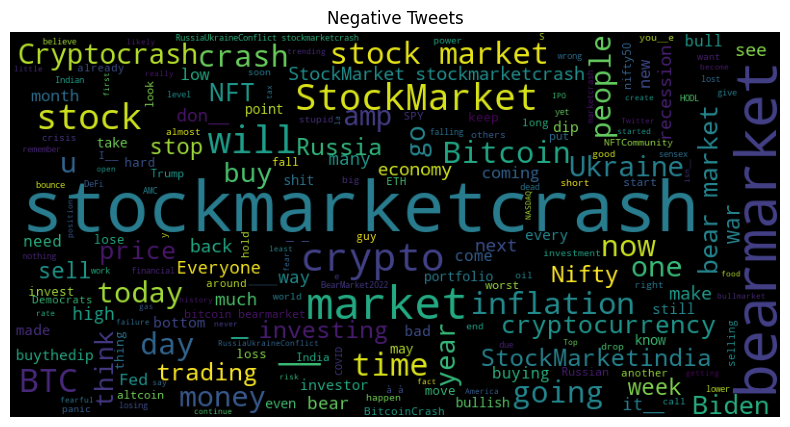

In [9]:
negative_tweets = df.filter(col("text_sentiment") == 2).select("text").toPandas()["text"]
generate_wordcloud(negative_tweets, "Negative Tweets")

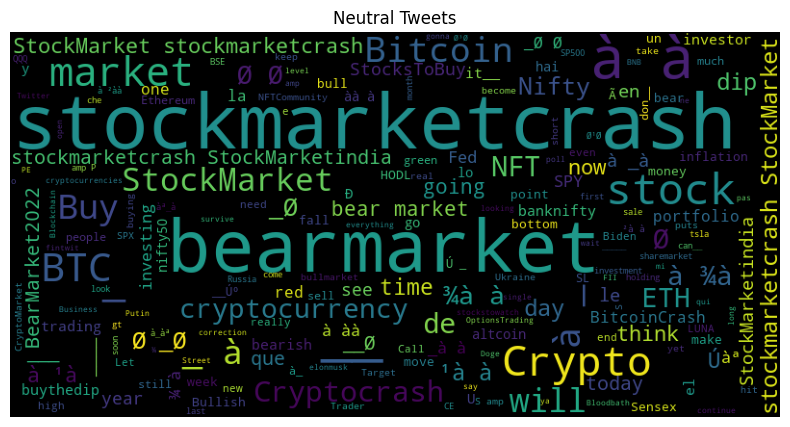

In [10]:
neutral_tweets = df.filter(col("text_sentiment") == 0).select("text").toPandas()["text"]
generate_wordcloud(neutral_tweets, "Neutral Tweets")

## 1. Baseline Model: Logistic regression + TFIDF


In [11]:
df = df.withColumn("cleaned_text", regexp_replace(
    col("text"),
    r'http\S+|www\S+|@\w+|#\w+|\$[A-Za-z]+', ''  # Remove URLs, hashtags, mentions, etc.
))

df.show()

+--------------------+--------------+--------------------+
|                text|text_sentiment|        cleaned_text|
+--------------------+--------------+--------------------+
|#bearmarket i exp...|             0| i expect retest ...|
|Mientras estÃ©s v...|             0|Mientras estÃ©s v...|
|#ETH is gone_¦ð_#...|             0|       is gone_¦ð_  |
|It__ finally here...|             0|It__ finally here!  |
|I don__ see it. #...|             0|    I don__ see it. |
|$TSLA is cheap! J...|             0| is cheap! Just s...|
|I am a trader, wh...|             0|I am a trader, wh...|
|OpenSea removed t...|             0|OpenSea removed t...|
|Bhai sare Fintwit...|             0|Bhai sare Fintwit...|
|   #stockmarketcrash|             0|                    |
|R.I.P El Salvador...|             0|R.I.P El Salvador...|
|à¤¹à¤®à¥_ à¤¤à à¤...|             0|à¤¹à¤®à¥_ à¤¤à à¤...|
|2021-\nDad - wher...|             0|2021-\nDad - wher...|
|#bearmarket  too ...|             0|        too much re

In [12]:
tokenizer = Tokenizer(inputCol="cleaned_text", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
hashing_tf = HashingTF(inputCol="filtered_words", outputCol="raw_features", numFeatures=100000)
idf = IDF(inputCol="raw_features", outputCol="features")
lr = LogisticRegression(featuresCol="features", labelCol="text_sentiment")

In [39]:
pipeline = Pipeline(stages=[tokenizer, remover, hashing_tf, idf, lr])
train, test = df.randomSplit([0.75, 0.25], seed=12)
model = pipeline.fit(train)

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

predictions = model.transform(test)

evaluator = MulticlassClassificationEvaluator(labelCol="text_sentiment", metricName="accuracy")

print(f"Accuracy: {evaluator.evaluate(predictions):.4f}")
pdf = predictions.select("text_sentiment", "prediction").toPandas()


Accuracy: 0.5465


# 2. Comparison with data analytics models (Random Forest, NaiveBayes and Decision Tree)

In [15]:
from pyspark.ml.classification import RandomForestClassifier, NaiveBayes, DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

train, test = df.randomSplit([0.75, 0.25], seed=12)

rf = RandomForestClassifier(featuresCol="features", labelCol="text_sentiment")
nb = NaiveBayes(featuresCol="features", labelCol="text_sentiment")
dt = DecisionTreeClassifier(featuresCol="features", labelCol="text_sentiment")

common_stages = [tokenizer, remover, hashing_tf, idf]

pipeline_rf = Pipeline(stages=common_stages + [rf])
pipeline_nb = Pipeline(stages=common_stages + [nb])
pipeline_dt = Pipeline(stages=common_stages + [dt])

models = {
    "Random Forest (TF-IDF)": pipeline_rf,
    "Naive Bayes (TF-IDF)": pipeline_nb,
    "Decision Tree (TF-IDF)": pipeline_dt
}

results = {}

#training and testing each model
for name, pipeline in models.items():
    print(f"\n{name}")

    #train model
    model = pipeline.fit(train)

    #test model
    predictions = model.transform(test)

    #accuracy
    accuracy = evaluator.evaluate(predictions)
    print(f"{name} - Accuracy: {accuracy:.4f}")



Random Forest (TF-IDF)
Random Forest (TF-IDF) - Accuracy: 0.3810

Naive Bayes (TF-IDF)
Naive Bayes (TF-IDF) - Accuracy: 0.5193

Decision Tree (TF-IDF)
Decision Tree (TF-IDF) - Accuracy: 0.4422


# 3. Comparison with word embedding models (Word2Vec, GloVe)

In [98]:
from pyspark.ml.feature import Word2Vec

# Word2Vec Embedding
word2vec = Word2Vec(vectorSize=100, minCount=5, inputCol="filtered_words", outputCol="features")
pipeline_w2v = Pipeline(stages=[tokenizer, remover, word2vec, lr])
model_w2v = pipeline_w2v.fit(df)
accuracy_w2v = evaluator.evaluate(model_w2v.transform(df))
print(f"Word2Vec + LR Accuracy: {accuracy_w2v:.4f}")

Word2Vec + LR Accuracy: 0.5544


In [99]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import SQLTransformer
from sparknlp.base import *
from sparknlp.annotator import *

raw_df = df.select("text", "text_sentiment")

#glove
document_assembler = DocumentAssembler() \
    .setInputCol("text") \
    .setOutputCol("document")

tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("token")

glove = WordEmbeddingsModel.pretrained("glove_100d") \
    .setInputCols(["document", "token"]) \
    .setOutputCol("embeddings")

sentence_embeddings = SentenceEmbeddings() \
    .setInputCols(["document", "embeddings"]) \
    .setOutputCol("sentence_embeddings") \
    .setPoolingStrategy("AVERAGE")

embeddings_finisher = EmbeddingsFinisher() \
    .setInputCols(["sentence_embeddings"]) \
    .setOutputCols(["embeddings_array"]) \
    .setOutputAsVector(True)

glove_100d download started this may take some time.
Approximate size to download 145.3 MB
[OK!]


In [100]:
#from glove embeddings, transform to a single vector to fit lr regression
sql_transformer = SQLTransformer(
    statement="SELECT *, embeddings_array[0] as features FROM __THIS__"
)

#glove pipeline
pipeline = Pipeline(stages=[
    document_assembler,
    tokenizer,
    glove,
    sentence_embeddings,
    embeddings_finisher,
    sql_transformer,
    lr
])

train, test = raw_df.randomSplit([0.75, 0.25])
model = pipeline.fit(train)
predictions = model.transform(test)

#evaluation
evaluator = MulticlassClassificationEvaluator(
    labelCol="text_sentiment",
    predictionCol="prediction",
    metricName="accuracy"
)
print(f"GloVe + LR Accuracy: {evaluator.evaluate(predictions)}")

GloVe + LR Accuracy: 0.5785714285714286


# 4. Improvement of models

In [101]:
from pyspark.ml.classification import GBTClassifier

# Gradient Boosting Tree as an ensemble method
gbt = GBTClassifier(labelCol='text_sentiment', featuresCol='features')

# Fit the model
gbt_model = pipeline.fit(df)
gbt_predictions = gbt_model.transform(df)

In [102]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Evaluate Gradient Boosting Tree model
gbt_evaluator = MulticlassClassificationEvaluator(labelCol="text_sentiment", predictionCol="prediction", metricName="accuracy")
gbt_accuracy = gbt_evaluator.evaluate(gbt_predictions)

print(f"Gradient Boosting Tree Accuracy: {gbt_accuracy}")

Gradient Boosting Tree Accuracy: 0.6702127659574468


1. Improving Random Forest with Hyperparameter Tuning

In [15]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.feature import Tokenizer, HashingTF, IDF
from pyspark.ml import Pipeline

# Hyperparameter tuning for Random Forest
paramGrid_rf = (ParamGridBuilder()
                .addGrid(rf.numTrees, [50, 100])
                .addGrid(rf.maxDepth, [10, 15, 20])
                .build())

crossval_rf = CrossValidator(estimator=pipeline_rf,
                              estimatorParamMaps=paramGrid_rf,
                              evaluator=MulticlassClassificationEvaluator(labelCol="text_sentiment", metricName="accuracy"),
                              numFolds=3)

# Fit the model
cv_rf_model = crossval_rf.fit(df)
rf_best_score = max(cv_rf_model.avgMetrics)

print(f"Best Random Forest Score: {rf_best_score}")

Best Random Forest Score: 0.4699441571707153


2. Improving Naive Bayes with Hyperparameter Tuning

In [17]:
from pyspark.ml.classification import NaiveBayes

    
# Hyperparameter tuning for Naive Bayes
paramGrid_nb = (ParamGridBuilder()
                .addGrid(nb.smoothing, [0.1, 1.0, 2.0])
#                 .addGrid(ngram.n, [1, 2])
#                 .addGrid(hashing_tf.numFeatures, [2**16, 2**14])
#                 .addGrid(idf.minDocFreq, [2, 3, 4]) # times at least appear in document 
                .build())

crossval_nb = CrossValidator(estimator=pipeline_nb,
                              estimatorParamMaps=paramGrid_nb,
                              evaluator=MulticlassClassificationEvaluator(labelCol="text_sentiment", metricName="accuracy"),
                              numFolds=3)

# Fit the model
cv_nb_model = crossval_nb.fit(df)
nb_best_score = max(cv_nb_model.avgMetrics)

print(f"Best Naive Bayes Score: {nb_best_score}")

Best Naive Bayes Score: 0.5187943388627948


3. Improving Decision Tree with Hyperparameter Tuning

In [18]:
from pyspark.ml.classification import DecisionTreeClassifier

# Hyperparameter tuning for Decision Tree
paramGrid_dt = (ParamGridBuilder()
                .addGrid(dt.maxDepth, [25,30])
                .addGrid(dt.minInstancesPerNode, [3, 5])
                .build())

crossval_dt = CrossValidator(estimator=pipeline_dt,
                              estimatorParamMaps=paramGrid_dt,
                              evaluator=MulticlassClassificationEvaluator(labelCol="text_sentiment", metricName="accuracy"),
                              numFolds=3)

# Fit the model
cv_dt_model = crossval_dt.fit(df)
dt_best_score = max(cv_dt_model.avgMetrics)

print(f"Best Decision Tree Score: {dt_best_score}")

Best Decision Tree Score: 0.518231164825794


Ensemble models

In [120]:
train, test = df.randomSplit([0.75, 0.25], seed=12)

# Make predictions
rf_predictions = cv_rf_model.transform(test)
nb_predictions = cv_nb_model.transform(test)
dt_predictions = cv_dt_model.transform(test)

# Combine predictions using Voting Classifier concept
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

# Create a DataFrame with predictions from each model
predictions = rf_predictions.select("features", "text_sentiment", "prediction").withColumnRenamed("prediction", "rf_prediction") \
    .join(nb_predictions.select("features",  "prediction").withColumnRenamed("prediction", "nb_prediction"), "features") \
    .join(dt_predictions.select("features",  "prediction").withColumnRenamed("prediction", "dt_prediction"), "features")

# Voting mechanism: Majority vote
predictions = predictions.withColumn("final_prediction",
    F.when((F.col("rf_prediction") == 1) & (F.col("nb_prediction") == 1), 1).otherwise(
    F.when((F.col("nb_prediction") == 1) & (F.col("dt_prediction") == 1), 1).otherwise(
    F.when((F.col("dt_prediction") == 1) & (F.col("rf_prediction") == 1), 1).otherwise(

    F.when((F.col("rf_prediction") == 0) & (F.col("nb_prediction") == 0), 0).otherwise(
    F.when((F.col("nb_prediction") == 0) & (F.col("dt_prediction") == 0), 0).otherwise(
    F.when((F.col("dt_prediction") == 0) & (F.col("rf_prediction") == 0), 0).otherwise(

    F.when((F.col("rf_prediction") == 2) & (F.col("nb_prediction") == 2), 2).otherwise(
    F.when((F.col("nb_prediction") == 2) & (F.col("dt_prediction") == 2), 2).otherwise(
    F.when((F.col("dt_prediction") == 2) & (F.col("rf_prediction") == 2), 2).otherwise(0))))))))))

# change the cloumn "final_prediction" data type to Double
predictions = predictions.withColumn("final_prediction", col("final_prediction").cast(DoubleType()))

#Evaluate the ensemble model
evaluator = MulticlassClassificationEvaluator(labelCol="text_sentiment", predictionCol="final_prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)

predictions.show()

print(f"Voting Ensemble model accuracy: {accuracy}")

+--------------------+--------------+-------------+-------------+-------------+----------------+
|            features|text_sentiment|rf_prediction|nb_prediction|dt_prediction|final_prediction|
+--------------------+--------------+-------------+-------------+-------------+----------------+
|(100000,[6500,827...|             2|          0.0|          2.0|          0.0|             0.0|
|(100000,[2540,151...|             1|          1.0|          1.0|          1.0|             1.0|
|(100000,[28094,29...|             0|          1.0|          0.0|          0.0|             0.0|
|(100000,[68897,88...|             0|          0.0|          0.0|          0.0|             0.0|
|(100000,[1670,933...|             0|          0.0|          0.0|          0.0|             0.0|
|(100000,[2790,229...|             1|          0.0|          1.0|          1.0|             1.0|
|(100000,[1511,233...|             1|          1.0|          1.0|          1.0|             1.0|
|(100000,[65067,93...|        

In [121]:
from pyspark.ml.feature import VectorAssembler

# Prepare meta-features DataFrame
meta_features = rf_predictions.select("text_sentiment", "prediction").withColumnRenamed("prediction", "rf_pred") \
    .join(nb_predictions.select("text_sentiment", "prediction").withColumnRenamed("prediction", "nb_pred"), on="text_sentiment") \
    .join(dt_predictions.select("text_sentiment", "prediction").withColumnRenamed("prediction", "dt_pred"), on="text_sentiment")

#Create the features for the meta-model
meta_features_assembler = VectorAssembler(inputCols=["rf_pred", "nb_pred", "dt_pred"], outputCol="meta_features")
meta_features = meta_features_assembler.transform(meta_features).select("text_sentiment", "meta_features")


train_meta, test_meta = meta_features.randomSplit([0.75, 0.25], seed=12)

# Train the meta-model
meta_lr = LogisticRegression(labelCol="text_sentiment", featuresCol="meta_features")
meta_model = meta_lr.fit(meta_features)

#Generate test predictions from base models
rf_test_predictions = model.transform(test)
nb_test_predictions = rf_model.transform(test)
dt_test_predictions = dt_model.transform(test)

# Prepare test meta-features
test_meta_features = rf_test_predictions.select("text_sentiment", "prediction").withColumnRenamed("prediction", "rf_pred") \
    .join(nb_test_predictions.select("text_sentiment", "prediction").withColumnRenamed("prediction", "nb_pred"), on="text_sentiment") \
    .join(dt_test_predictions.select("text_sentiment", "prediction").withColumnRenamed("prediction", "dt_pred"), on="text_sentiment")

# Create the features for the test meta-model
test_meta_features = meta_features_assembler.transform(test_meta_features).select("text_sentiment", "meta_features")

# Make predictions using the meta-model
final_predictions = meta_model.transform(test_meta_features)

final_predictions.show()
# Evaluate the model
evaluator = MulticlassClassificationEvaluator(labelCol="text_sentiment", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(final_predictions)

print(f"Stacking Ensemble Model Accuracy: {accuracy}")

+--------------+-------------+--------------------+--------------------+----------+
|text_sentiment|meta_features|       rawPrediction|         probability|prediction|
+--------------+-------------+--------------------+--------------------+----------+
|             2|[2.0,1.0,0.0]|[-3.4386099820114...|[7.69904993117359...|       1.0|
|             2|[2.0,1.0,0.0]|[-3.4386099820114...|[7.69904993117359...|       1.0|
|             2|[2.0,1.0,0.0]|[-3.4386099820114...|[7.69904993117359...|       1.0|
|             2|[2.0,1.0,0.0]|[-3.4386099820114...|[7.69904993117359...|       1.0|
|             2|[2.0,1.0,0.0]|[-3.4386099820114...|[7.69904993117359...|       1.0|
|             2|[2.0,1.0,0.0]|[-3.4386099820114...|[7.69904993117359...|       1.0|
|             2|[2.0,1.0,0.0]|[-3.4386099820114...|[7.69904993117359...|       1.0|
|             2|[2.0,1.0,0.0]|[-3.4386099820114...|[7.69904993117359...|       1.0|
|             2|[2.0,1.0,0.0]|[-3.4386099820114...|[7.69904993117359...|    

4.Data visulaization

In [13]:
df = df.withColumn("cleaned_text2", regexp_replace(
        regexp_replace(col("text"),
        r'http\S+|www\S+|@\w+|#\w+|\$[A-Za-z]+', ''  # Remove url, hashtags, etc
    ),
    r'[^\w\s]', ''  # Remove punctuation
))
df.show()

+--------------------+--------------+--------------------+--------------------+
|                text|text_sentiment|        cleaned_text|       cleaned_text2|
+--------------------+--------------+--------------------+--------------------+
|#bearmarket i exp...|             0| i expect retest ...| i expect retest ...|
|Mientras estÃ©s v...|             0|Mientras estÃ©s v...|Mientras ests ven...|
|#ETH is gone_¦ð_#...|             0|       is gone_¦ð_  |         is gone__  |
|It__ finally here...|             0|It__ finally here!  | It__ finally here  |
|I don__ see it. #...|             0|    I don__ see it. |     I don__ see it |
|$TSLA is cheap! J...|             0| is cheap! Just s...| is cheap Just sa...|
|I am a trader, wh...|             0|I am a trader, wh...|I am a trader who...|
|OpenSea removed t...|             0|OpenSea removed t...|OpenSea removed t...|
|Bhai sare Fintwit...|             0|Bhai sare Fintwit...|Bhai sare Fintwit...|
|   #stockmarketcrash|             0|   

In [14]:
num_cols= ['cleaned_text2','text_sentiment']
df.select(num_cols).describe().show()

+-------+--------------------+------------------+
|summary|       cleaned_text2|    text_sentiment|
+-------+--------------------+------------------+
|  count|                1692|              1692|
|   mean|                NULL|0.9515366430260047|
| stddev|                NULL|0.7932394729585573|
|    min|                    |                 0|
|    max|you bitch ass  di...|                 2|
+-------+--------------------+------------------+



In [15]:
pandas_df = df.toPandas()
mean = pandas_df['text_sentiment'].mean()
mode = pandas_df['text_sentiment'].mode()[0]
median = pandas_df['text_sentiment'].median()


minimum = pandas_df['text_sentiment'].min()
maximum = pandas_df['text_sentiment'].max()
range_value = maximum - minimum
variance = pandas_df['text_sentiment'].var()
std_dev = pandas_df['text_sentiment'].std()
quartiles = pandas_df['text_sentiment'].quantile([0.25, 0.5, 0.75])

print(f"Mean: {mean}")
print(f"Mode: {mode}")
print(f"Median: {median}\n")

print(f"Range: {range_value}")
print(f"Variance: {variance}")
print(f"Standard Deviation: {std_dev}")
print(f"Minimum: {minimum}")
print(f"Maximum: {maximum}")
print(f"Quartiles:\n{quartiles}")

Mean: 0.9515366430260047
Mode: 1
Median: 1.0

Range: 2
Variance: 0.6292288614595697
Standard Deviation: 0.7932394729585572
Minimum: 0
Maximum: 2
Quartiles:
0.25    0.0
0.50    1.0
0.75    2.0
Name: text_sentiment, dtype: float64


In [16]:
pip install matplotlib wordcloud

Note: you may need to restart the kernel to use updated packages.


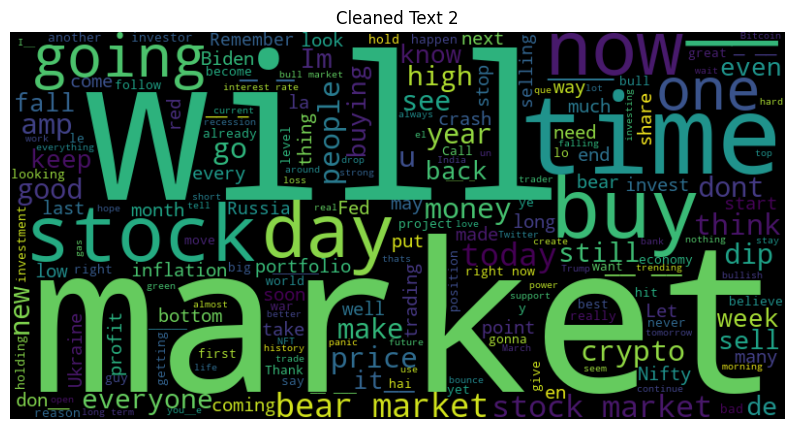

In [17]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

pandas_df = df.toPandas()
text_combined = ' '.join(pandas_df['cleaned_text2'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text_combined)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Cleaned Text 2')
plt.show()

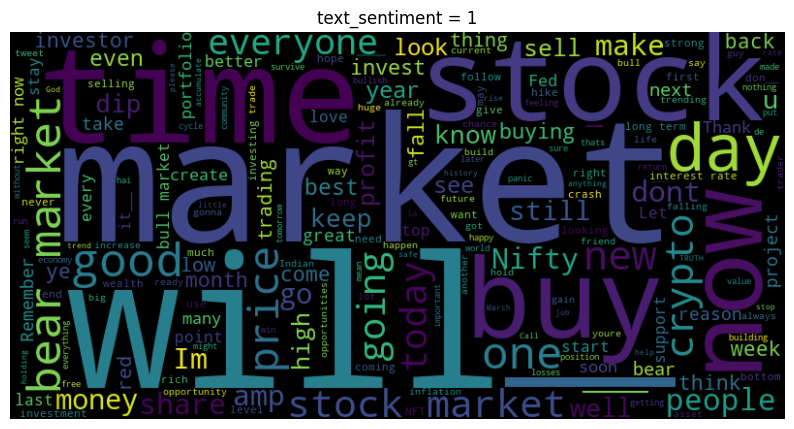

In [18]:
filtered_df = pandas_df[pandas_df['text_sentiment'] == 1]
text_combined = ' '.join(filtered_df['cleaned_text2'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text_combined)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('text_sentiment = 1')
plt.show()

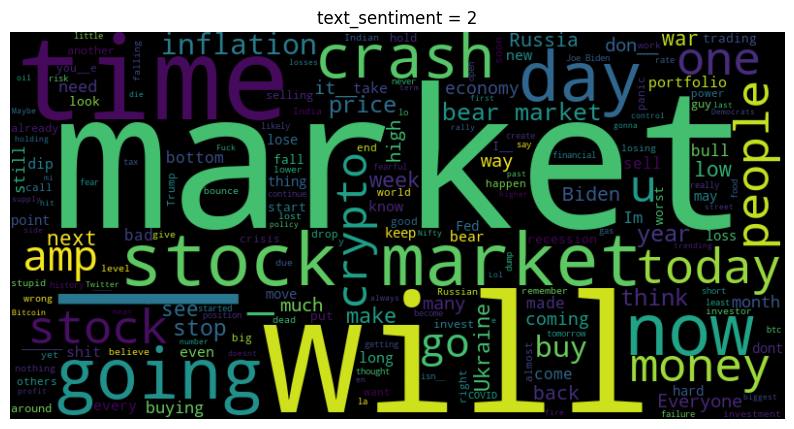

In [19]:
filtered_df = pandas_df[pandas_df['text_sentiment'] == 2]
text_combined = ' '.join(filtered_df['cleaned_text2'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text_combined)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('text_sentiment = 2')
plt.show()

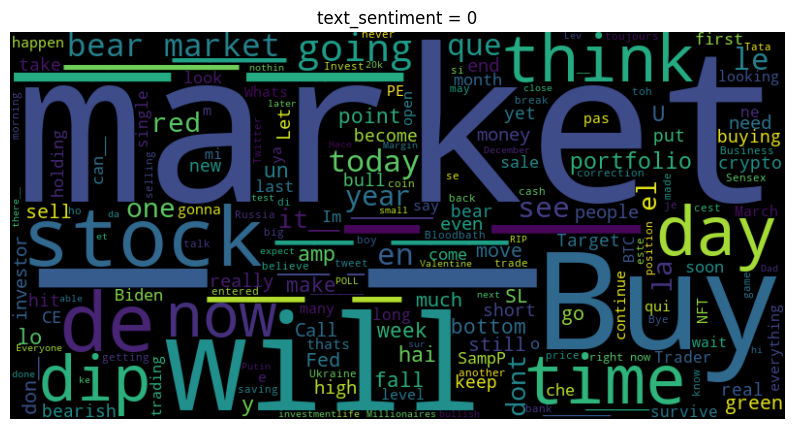

In [20]:
filtered_df = pandas_df[pandas_df['text_sentiment'] == 0]
text_combined = ' '.join(filtered_df['cleaned_text2'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text_combined)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('text_sentiment = 0')
plt.show()

In [21]:
# import nltk
# nltk.download('averaged_perceptron_tagger_eng')
# nltk.download('punkt_tab')

In [22]:
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [23]:
cleaned_texts = " ".join(df.select("cleaned_text2").rdd.flatMap(lambda x: x).collect())

tokens = word_tokenize(cleaned_texts)
tagged = pos_tag(tokens)

n_filtered_words = [word for word, tag in tagged if tag.startswith(('NN'))]
adj_filtered_words = [word for word, tag in tagged if tag.startswith(('JJ'))]
v_filtered_words = [word for word, tag in tagged if tag.startswith(('V'))]

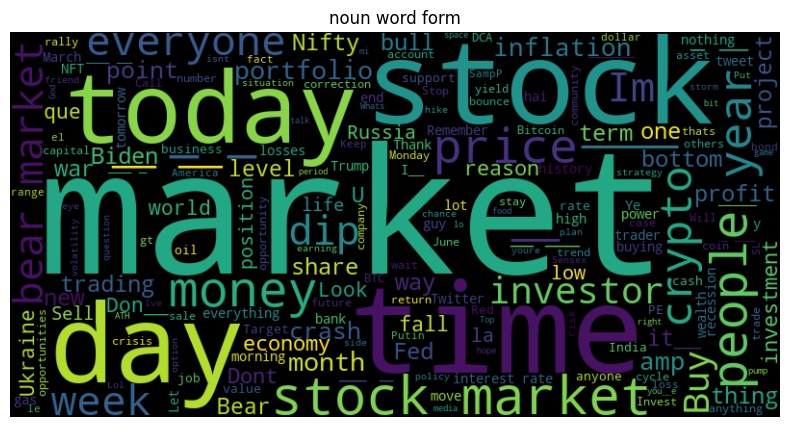

In [24]:
filtered_text = " ".join(n_filtered_words)

wordcloud = WordCloud(width=800, height=400, background_color='black').generate(filtered_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('noun word form')
plt.show()

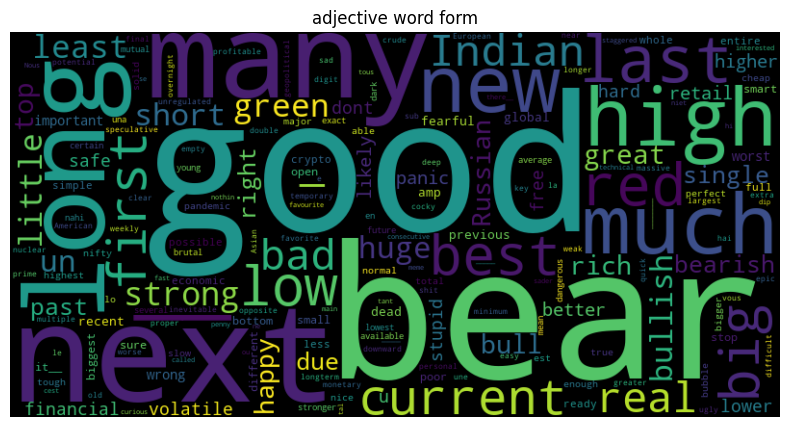

In [25]:
filtered_text = " ".join(adj_filtered_words)

wordcloud = WordCloud(width=800, height=400, background_color='black').generate(filtered_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('adjective word form')
plt.show()

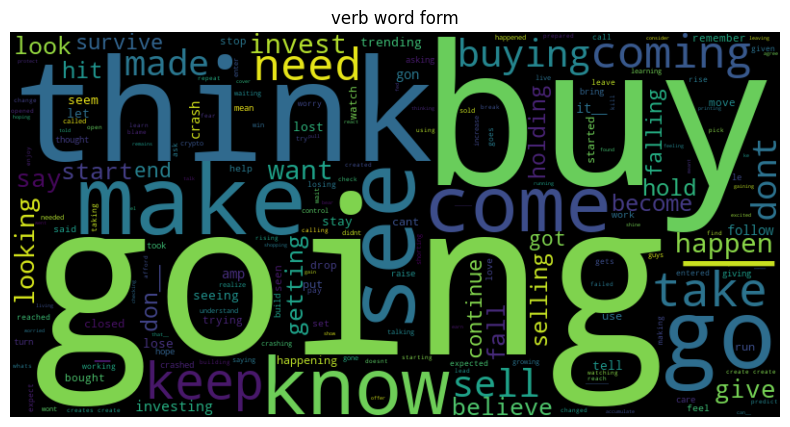

In [26]:
filtered_text = " ".join(v_filtered_words)

wordcloud = WordCloud(width=800, height=400, background_color='black').generate(filtered_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('verb word form')
plt.show()

In [27]:
import re
from collections import Counter
import pandas as pd

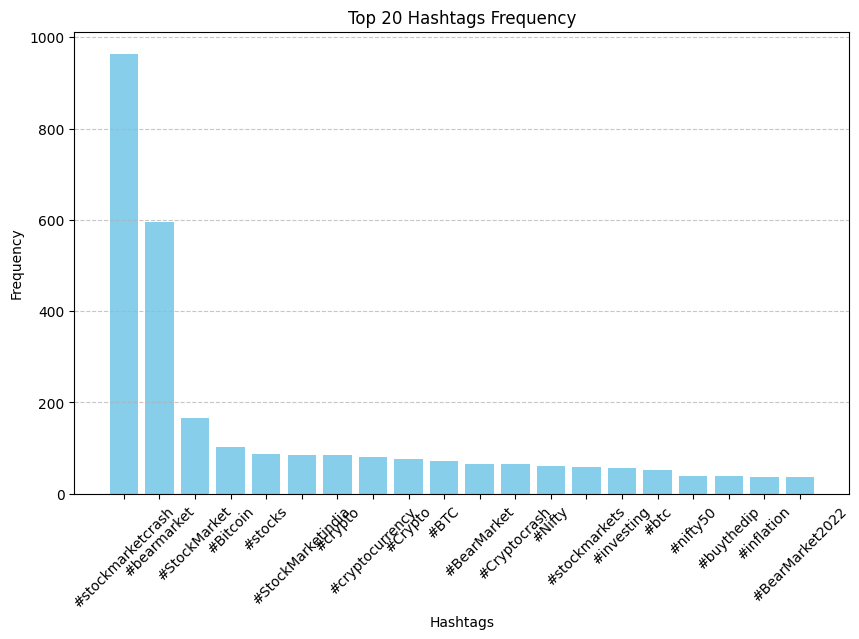

In [28]:
pandas_df = df.toPandas()

def extract_hashtags(text):
    hashtags = re.findall(r'#\w+', text)
    return hashtags

all_hashtags = []
pandas_df['text'].dropna().apply(lambda x: all_hashtags.extend(extract_hashtags(x)))

hashtag_counts = Counter(all_hashtags)

hashtag_df = pd.DataFrame(hashtag_counts.items(), columns=['Hashtag', 'Frequency'])
hashtag_df = hashtag_df.sort_values(by='Frequency', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.bar(hashtag_df['Hashtag'], hashtag_df['Frequency'], color='skyblue')
plt.title('Top 20 Hashtags Frequency')
plt.xlabel('Hashtags')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

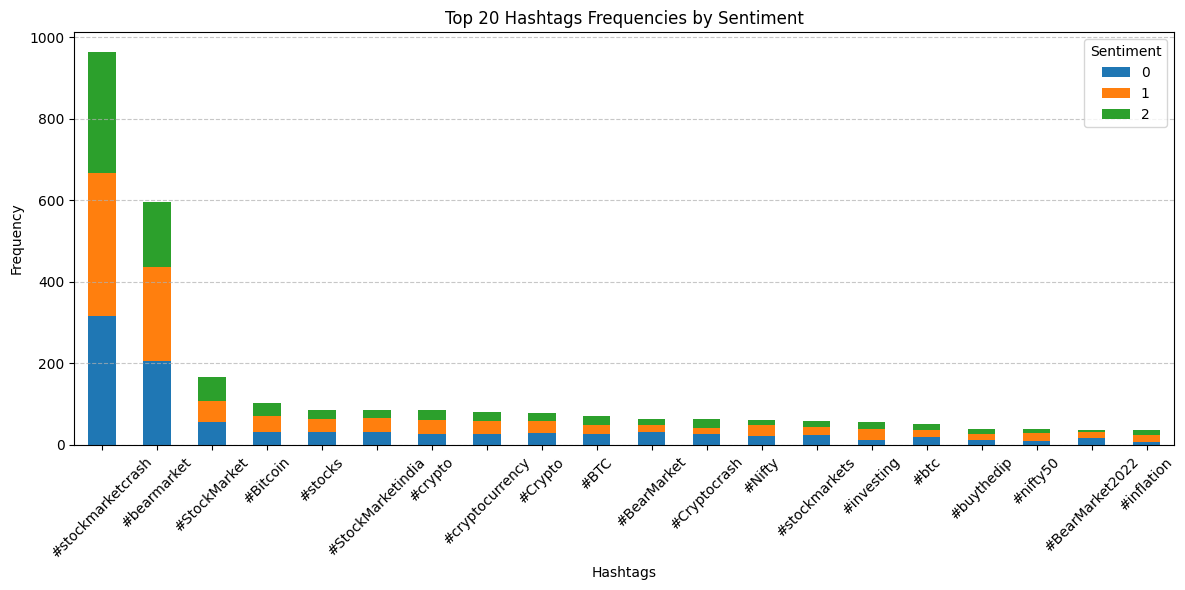

In [29]:
import matplotlib.pyplot as plt

pandas_df = df.toPandas()

def extract_hashtags_with_sentiment(row):
    hashtags = re.findall(r'#\w+', row['text'])
    sentiment = row['text_sentiment']
    return [(hashtag, sentiment) for hashtag in hashtags]

all_hashtags_with_sentiment = []
pandas_df.dropna(subset=['text']).apply(lambda row: all_hashtags_with_sentiment.extend(extract_hashtags_with_sentiment(row)), axis=1)

hashtag_sentiment_df = pd.DataFrame(all_hashtags_with_sentiment, columns=['Hashtag', 'Sentiment'])

hashtag_counts = hashtag_sentiment_df.groupby(['Hashtag', 'Sentiment']).size().unstack(fill_value=0)

top_hashtags = hashtag_counts.sum(axis=1).nlargest(20).index
top_hashtag_counts = hashtag_counts.loc[top_hashtags]

top_hashtag_counts.plot(kind='bar', stacked=True, figsize=(12, 6), color=plt.cm.tab10.colors)
plt.title('Top 20 Hashtags Frequencies by Sentiment')
plt.xlabel('Hashtags')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

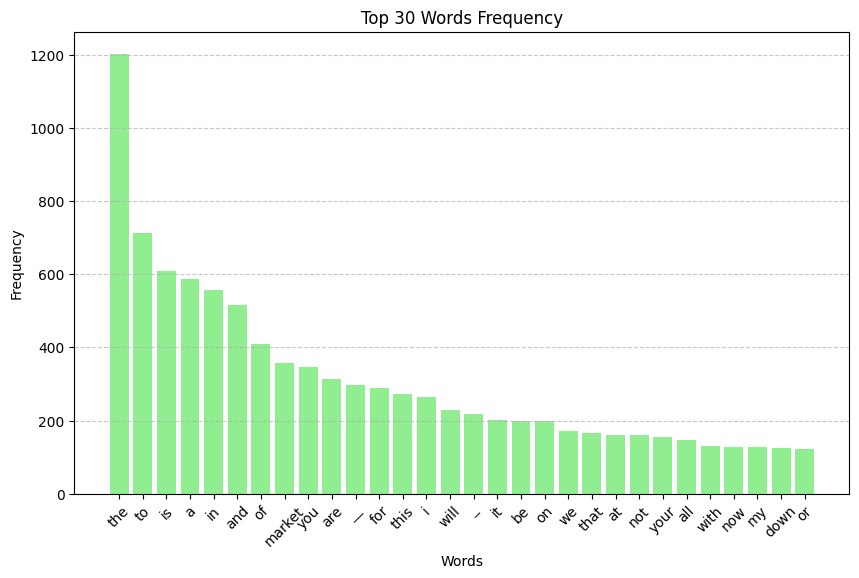

In [30]:
pandas_df = df.toPandas()

text_combined = ' '.join(pandas_df['cleaned_text2'].dropna())

words = re.findall(r'\w+', text_combined.lower())

word_counts = Counter(words)

word_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency'])
word_df = word_df.sort_values(by='Frequency', ascending=False).head(30)

plt.figure(figsize=(10, 6))
plt.bar(word_df['Word'], word_df['Frequency'], color='lightgreen')
plt.title('Top 30 Words Frequency')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

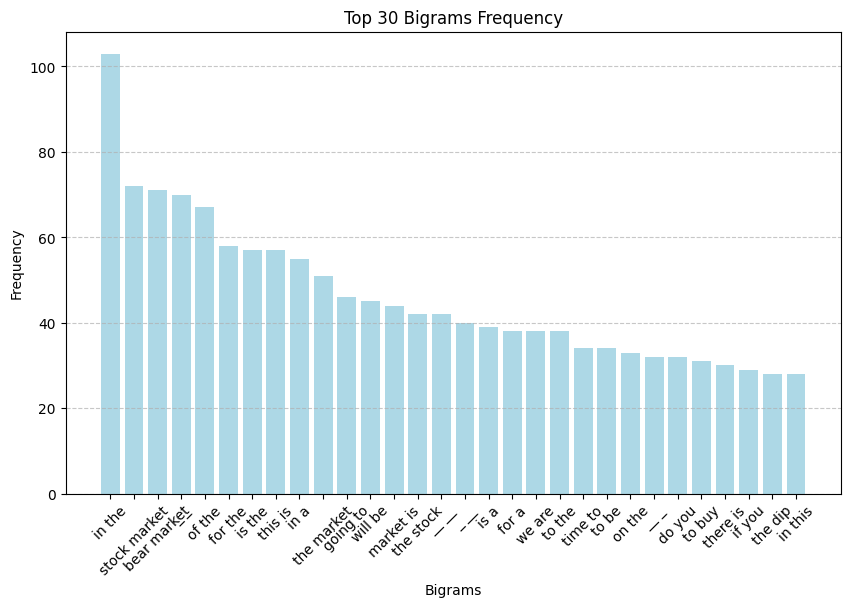

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
from nltk import ngrams

pandas_df = df.toPandas()

text_combined = ' '.join(pandas_df['cleaned_text2'].dropna())

words = re.findall(r'\w+', text_combined.lower())

bigrams = list(ngrams(words, 2))

bigram_counts = Counter(bigrams)

bigram_df = pd.DataFrame(bigram_counts.items(), columns=['Bigram', 'Frequency'])

bigram_df['Bigram'] = bigram_df['Bigram'].apply(lambda x: ' '.join(x))

top_bigrams = bigram_df.sort_values(by='Frequency', ascending=False).head(30)

plt.figure(figsize=(10, 6))
plt.bar(top_bigrams['Bigram'], top_bigrams['Frequency'], color='lightblue')
plt.title('Top 30 Bigrams Frequency')
plt.xlabel('Bigrams')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

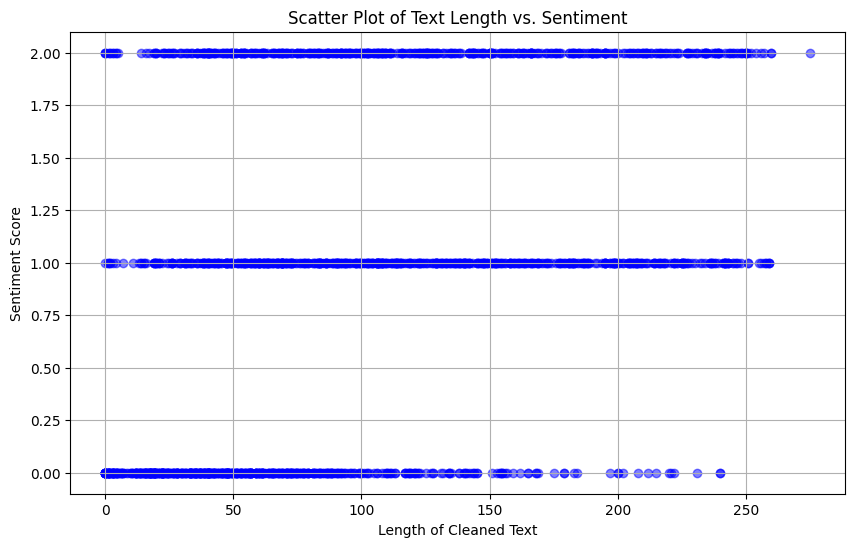

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

pandas_df = df.toPandas()

pandas_df['text_length'] = pandas_df['cleaned_text2'].dropna().apply(len)

scatter_df = pandas_df.dropna(subset=['text_length', 'text_sentiment'])

plt.figure(figsize=(10, 6))
plt.scatter(scatter_df['text_length'], scatter_df['text_sentiment'], alpha=0.5, color='blue')
plt.title('Scatter Plot of Text Length vs. Sentiment')
plt.xlabel('Length of Cleaned Text')
plt.ylabel('Sentiment Score')
plt.grid(True)
plt.show()

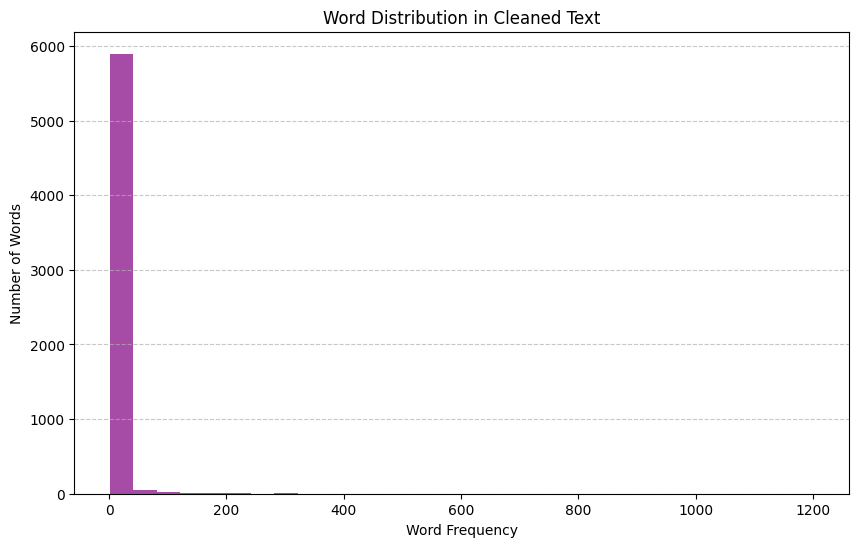

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

pandas_df = df.toPandas()

text_combined = ' '.join(pandas_df['cleaned_text2'].dropna())

words = re.findall(r'\w+', text_combined.lower())

word_counts = Counter(words)

word_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency'])

plt.figure(figsize=(10, 6))
plt.hist(word_df['Frequency'], bins=30, color='purple', alpha=0.7)
plt.title('Word Distribution in Cleaned Text')
plt.xlabel('Word Frequency')
plt.ylabel('Number of Words')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()